In [ ]:
#%pip install pandas
#%pip install 
#%pip install -U scikit-learn
#%pip install -U optbinning
#%pip install -U matplotlib
#import necessary libraries
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from optbinning import BinningProcess, Scorecard
from optbinning.scorecard import plot_auc_roc, plot_ks

import matplotlib.pyplot as plt

In [ ]:
#read in accepted customers
accepts = pd.read_csv('accepted_customers.csv')
accepts

,CHILDREN,PERS_H,AGE,TMADD,TMJOB1,TEL,NMBLOAN,FINLOAN,INCOME,EC_CARD,...,DIV,CASH,PRODUCT,RESID,NAT,PROF,CAR,CARDS,GB,_freq_
0,0,2,51,3,999,2,0,0,1000,1,...,1,1300,Furniture or Carpet,Lease,German,Others,Car,Cheque card,0,30
1,1,2,55,60,999,2,2,0,2900,0,...,1,900,Furniture or Carpet,Owner,German,Others,Car,no credit cards,0,30
2,0,1,50,72,999,2,2,0,2300,0,...,0,1100,Radio or TV or Hifi,Lease,German,Others,Without Vehicle,no credit cards,0,30
3,0,2,56,96,999,2,2,1,4000,0,...,0,7000,Furniture or Carpet,Lease,German,Civil Service,Car,no credit cards,0,30
4,0,1,52,120,999,2,0,0,0,1,...,0,1200,Furniture or Carpet,Lease,German,Others,Car,Cheque card,0,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,1,23,288,3,1,0,0,0,1,...,0,600,Radio or TV or Hifi,Lease,German,Others,Car,Cheque card,1,1
2996,0,1,26,312,3,2,0,1,2000,0,...,1,700,Radio or TV or Hifi,NaN,German,Others,Car,no credit cards,1,1
2997,1,2,36,12,0,2,0,0,1900,0,...,1,1200,Furniture or Carpet,NaN,German,Pensioner,Car,no credit cards,1,1
2998,0,1,28,24,0,1,0,0,1800,1,...,1,600,Dept. Store or Mail,NaN,German,Others,Car,Cheque card,1,1


In [ ]:
#ensuring that weights were assigned correctly
accepts[(accepts['GB']==0)&(accepts['_freq_']!=30)]

,CHILDREN,PERS_H,AGE,TMADD,TMJOB1,TEL,NMBLOAN,FINLOAN,INCOME,EC_CARD,...,DIV,CASH,PRODUCT,RESID,NAT,PROF,CAR,CARDS,GB,_freq_


In [ ]:
#ensuring that weights were assigned correctly
accepts[(accepts['GB']==1)&(accepts['_freq_']==30)]

,CHILDREN,PERS_H,AGE,TMADD,TMJOB1,TEL,NMBLOAN,FINLOAN,INCOME,EC_CARD,...,DIV,CASH,PRODUCT,RESID,NAT,PROF,CAR,CARDS,GB,_freq_


In [ ]:
#train test split on accepted customers
train, test = train_test_split(accepts, test_size=0.3, random_state=1234)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

train.head(5)

Train shape: (2100, 24)
Test shape : (900, 24)


,CHILDREN,PERS_H,AGE,TMADD,TMJOB1,TEL,NMBLOAN,FINLOAN,INCOME,EC_CARD,...,DIV,CASH,PRODUCT,RESID,NAT,PROF,CAR,CARDS,GB,_freq_
1970,3,5,40,66,54,2,2,1,3000,0,...,1,800,Leisure,Lease,German,Others,Car,no credit cards,1,1
2324,0,1,24,312,30,2,0,1,2200,0,...,1,1300,Radio or TV or Hifi,Lease,German,Military Service,Car,no credit cards,1,1
1885,1,2,22,3,60,2,0,0,2000,0,...,1,1800,Radio or TV or Hifi,Lease,German,Others,Car,no credit cards,1,1
2371,0,1,36,144,27,2,0,0,0,1,...,0,500,Dept. Store or Mail,Lease,German,Others,Without Vehicle,Cheque card,1,1
1023,0,1,42,60,30,2,2,1,1600,0,...,0,2500,Furniture or Carpet,Lease,German,Others,Without Vehicle,no credit cards,0,30


In [ ]:
# Ensure bad is numeric 0/1
train['GB'] = pd.to_numeric(train['GB'], errors="coerce").astype(int)
test['GB']  = pd.to_numeric(test['GB'],  errors="coerce").astype(int)

if '_freq_' not in train.columns:
    train['_freq_'] = 1.0
if '_freq_' not in test.columns:
    test['_freq_'] = 1.0

train[['GB', '_freq_']].head()

,GB,_freq_
1970,1,1
2324,1,1
1885,1,1
2371,1,1
1023,0,30


In [ ]:
#binning columns with numerical variables 
colnames = list(train.columns)

for drop_col in ['GB', '_freq_']:
    if drop_col in colnames:
        colnames.remove(drop_col)

X_train = train[colnames]
y_train = train['GB']

selection_criteria = {'iv': {'min': 0.1, 'max': 1}}

categorical_vars = ['PRODUCT', 'NAT', 'PROF', 'CAR', 'CARDS', 'BUREAU', 'REGN', 'TEL', 'DIV', 'EC_CARD', 'FINLOAN', 'LOCATION', 'RESID']
categorical_vars = [c for c in categorical_vars if c in X_train.columns]

bin_proc = BinningProcess(
    variable_names=colnames,
    selection_criteria=selection_criteria,
    categorical_variables=categorical_vars
)

summary = bin_proc.fit(X_train, y_train).summary()
summary.sort_values('iv', ascending=False).head(15)

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
2,AGE,numerical,OPTIMAL,True,8,0.389083,0.047006,0.341598,0.111394
8,INCOME,numerical,OPTIMAL,True,8,0.268925,0.032929,0.287504,0.133748
21,CARDS,categorical,OPTIMAL,True,2,0.189327,0.023299,0.193474,0.382846
4,TMJOB1,numerical,OPTIMAL,True,8,0.17702,0.021569,0.220274,0.053874
1,PERS_H,numerical,OPTIMAL,True,4,0.176798,0.021889,0.214955,0.253062
9,EC_CARD,categorical,OPTIMAL,True,2,0.157998,0.019456,0.171809,0.312224
5,TEL,categorical,OPTIMAL,False,2,0.057385,0.007107,0.09124,0.093116
0,CHILDREN,numerical,OPTIMAL,False,4,0.047069,0.00587,0.111133,0.008188
19,PROF,categorical,OPTIMAL,False,4,0.045712,0.005667,0.092525,0.027403
3,TMADD,numerical,OPTIMAL,False,4,0.040261,0.005009,0.098356,0.094559


In [ ]:
#fit scorecard on train data
estimator = LogisticRegression(solver="lbfgs", max_iter=2000)

scorecard = Scorecard(
    binning_process=bin_proc,
    estimator=estimator,
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": 50,
        "scorecard_points": 500,
        "odds": 20
    }
)

scorecard.fit(X_train, y_train, sample_weight=train['_freq_'])

,binning_process,BinningProces... 'CARDS'])
,estimator,LogisticRegre...max_iter=2000)
,scaling_method,'pdo_odds'
,scaling_method_params,"{'odds': 20, 'pdo': 50, 'scorecard_points': 500}"
,intercept_based,False
,reverse_scorecard,False
,rounding,False
,verbose,False
,variable_names,"['CHILDREN', 'PERS_H', ...]"
,max_n_prebins,20
,min_prebin_size,0.05


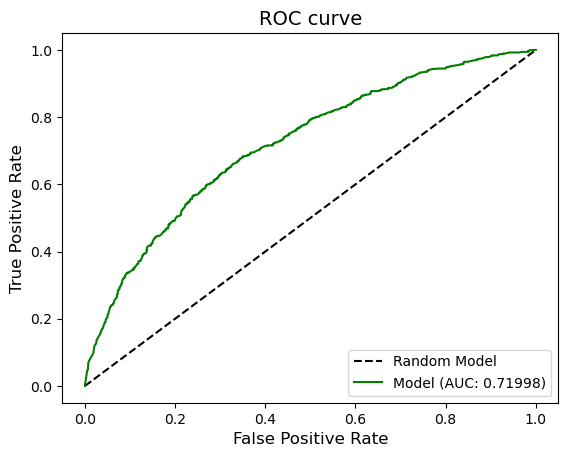

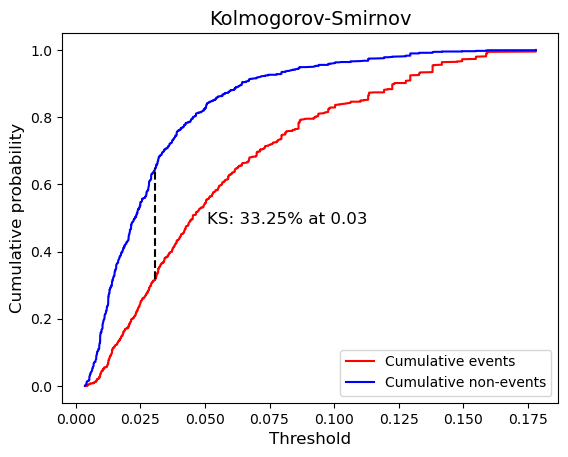

In [ ]:
#model evaluation of initial scorecard on train data
y_pred_train = scorecard.predict_proba(X_train)[:, 1]

plot_auc_roc(y_train, y_pred_train)
plt.show()

plot_ks(y_train, y_pred_train)
plt.show()

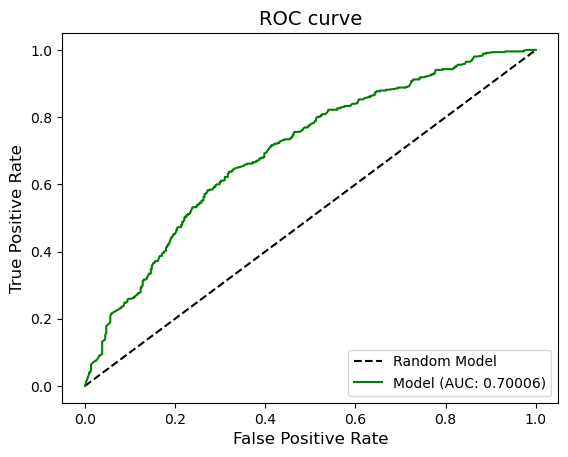

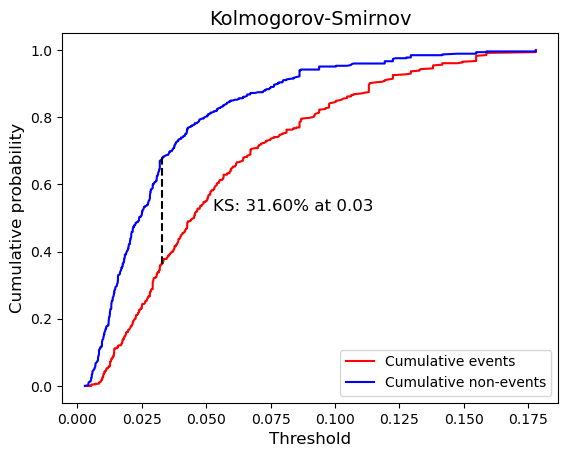

In [ ]:
#model evaluation of initial scorecard on test data
X_test = test[colnames]
y_test = test['GB']

y_pred_test = scorecard.predict_proba(X_test)[:, 1]

plot_auc_roc(y_test, y_pred_test)
plt.show()

plot_ks(y_test, y_pred_test)
plt.show()

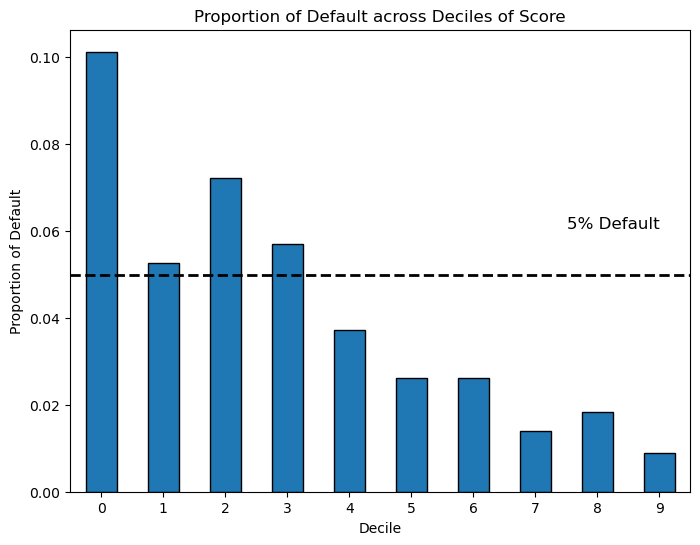

In [ ]:
# generate scores and a decile PD plot on initial scorecard from accepted customers data
# Recreate canonical split (robust to running this chunk standalone)
accepts = pd.read_csv('accepted_customers.csv')
train_tmp, test_tmp = train_test_split(accepts, test_size=0.3, random_state=1234)

test_final = test_tmp.copy()

# Ensure weight exists
if '_freq_' not in test_final.columns:
    test_final['_freq_'] = 1.0

# Score using the fitted optbinning scorecard and the predictor list `colnames`
test_final['score'] = scorecard.score(test_final[colnames])

test_final[['score', 'GB']].head()

good_weight = 30

test_final["decile"] = pd.qcut(test_final["score"], 10, labels=False)

# Counts by decile
bad_ct = test_final.loc[test_final['GB'] == 1].groupby("decile").size()
good_ct = test_final.loc[test_final['GB'] == 0].groupby("decile").size()

# Align indices to ensure 0..9 exist
all_dec = pd.Index(range(10), name="decile")
bad_ct = bad_ct.reindex(all_dec, fill_value=0)
good_ct = good_ct.reindex(all_dec, fill_value=0)

PD = bad_ct / (good_ct * good_weight + bad_ct)

plt.figure(figsize=(8, 6))
PD.plot(kind="bar", edgecolor="black")
plt.axhline(y=0.05, color="black", linestyle="--", linewidth=2)
plt.text(x=9, y=0.06, s="5% Default", color="black", ha="right", va="bottom", fontsize=12)

plt.title("Proportion of Default across Deciles of Score")
plt.xlabel("Decile")
plt.ylabel("Proportion of Default")
plt.xticks(rotation=0)
plt.show()

In [21]:
# reject inference - combine accepts with subset of rejects
rejects_path = "rejected_customers.csv"

if os.path.exists(rejects_path):
    rejects = pd.read_csv(rejects_path)

    ###################################
    # add in identifyer
    rejects['is_reject'] = 1
    accepts['is_reject'] = 0
    ###################################

    # Ensure the rejects file has the predictor columns needed
    missing = [c for c in colnames if c not in rejects.columns]
    if missing:
        raise ValueError(f"rejected_customers.csv is missing required columns: {missing}")

    X_r = rejects[colnames].copy()
    rejects["y_pred"] = scorecard.predict_proba(X_r)[:, 1]

    cutoff = 0.06
    rejects['GB'] = (rejects["y_pred"] > cutoff).astype(int)

    rejects['_freq_'] = rejects['GB'].apply(lambda x: 30 if x == 0 else 1.0)
    rejects = rejects.drop(columns=["y_pred"])

    comb_hard = pd.concat([accepts, rejects], ignore_index=True)

    print("rejects loaded and combined. comb_hard shape:", comb_hard.shape)
    comb_hard.head()
else:
    print("No rejects.csv found — skipping reject inference section.")
comb_hard

rejects loaded and combined. comb_hard shape: (4500, 25)


,CHILDREN,PERS_H,AGE,TMADD,TMJOB1,TEL,NMBLOAN,FINLOAN,INCOME,EC_CARD,...,CASH,PRODUCT,RESID,NAT,PROF,CAR,CARDS,GB,_freq_,is_reject
0,0,2,51,3,999,2,0,0,1000,1,...,1300,Furniture or Carpet,Lease,German,Others,Car,Cheque card,0,30.0,0
1,1,2,55,60,999,2,2,0,2900,0,...,900,Furniture or Carpet,Owner,German,Others,Car,no credit cards,0,30.0,0
2,0,1,50,72,999,2,2,0,2300,0,...,1100,Radio or TV or Hifi,Lease,German,Others,Without Vehicle,no credit cards,0,30.0,0
3,0,2,56,96,999,2,2,1,4000,0,...,7000,Furniture or Carpet,Lease,German,Civil Service,Car,no credit cards,0,30.0,0
4,0,1,52,120,999,2,0,0,0,1,...,1200,Furniture or Carpet,Lease,German,Others,Car,Cheque card,0,30.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,0,1,23,30,3,2,1,0,2100,0,...,7000,Cars,Lease,German,Others,Car,no credit cards,1,1.0,1
4496,0,2,55,36,72,2,1,0,3400,0,...,3000,"Radio, TV, Hifi",Lease,Yugoslav,Others,Car,no credit cards,0,30.0,1
4497,1,3,42,0,30,1,2,1,1500,0,...,3000,Leisure,Lease,German,Others,Without Vehicle,no credit cards,0,30.0,1
4498,1,3,28,18,21,2,2,0,2500,0,...,100000,Cars,Lease,German,Others,Car,no credit cards,0,30.0,1


In [ ]:
#train test split on accepted customers
#comb_train, comb_test = train_test_split(comb_hard, test_size=0.3, random_state=1234)

#print("Train shape:", train.shape)
#print("Test shape :", test.shape)

#train.head(5)

comb_train, comb_test = train_test_split(comb_hard, test_size=0.3, random_state=1234, stratify=comb_hard["is_reject"]) 

print("Train shape:", comb_train.shape)
print("Test shape :", comb_test.shape)

comb_train.head(5)

# droppping `is_reject` that was used for stratification
comb_train = comb_train.drop(columns=['is_reject'])
comb_test = comb_test.drop(columns=['is_reject'])


Train shape: (3150, 25)
Test shape : (1350, 25)


,CHILDREN,PERS_H,AGE,TMADD,TMJOB1,TEL,NMBLOAN,FINLOAN,INCOME,EC_CARD,...,CASH,PRODUCT,RESID,NAT,PROF,CAR,CARDS,GB,_freq_,is_reject
2626,0,1,22,120,15,2,0,0,2000,0,...,1000,Radio or TV or Hifi,Lease,German,Military Service,Car,no credit cards,1,1.0,0
1678,1,3,39,21,120,2,1,1,3500,0,...,600,Cars,Lease,Others,Others,Car,no credit cards,1,1.0,0
2739,0,1,27,3,9,1,0,1,1500,0,...,1200,Furniture or Carpet,Lease,German,Others,Car,no credit cards,1,1.0,0
2676,0,2,45,18,12,1,0,0,2300,0,...,1600,Furniture or Carpet,Lease,German,Others,Without Vehicle,no credit cards,1,1.0,0
1750,0,1,65,96,96,2,0,0,1800,0,...,500,Dept. Store or Mail,NaN,German,Pensioner,Without Vehicle,no credit cards,1,1.0,0


In [25]:
#binning columns with numerical variables 
colnames = list(comb_train.columns)

for drop_col in ['GB', '_freq_']:
    if drop_col in colnames:
        colnames.remove(drop_col)

X_train_comb = comb_train[colnames]
y_train_comb = comb_train['GB']

selection_criteria = {'iv': {'min': 0.1, 'max': 1}}

categorical_vars = ['PRODUCT', 'NAT', 'PROF', 'CAR', 'CARDS', 'BUREAU', 'REGN', 'TEL', 'DIV', 'EC_CARD', 'FINLOAN', 'LOCATION', 'RESID']
categorical_vars = [c for c in categorical_vars if c in X_train_comb.columns]

bin_proc = BinningProcess(
    variable_names=colnames,
    selection_criteria=selection_criteria,
    categorical_variables=categorical_vars
)

summary = bin_proc.fit(X_train_comb, y_train_comb).summary()
summary.sort_values('iv', ascending=False).head(15)

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
2,AGE,numerical,OPTIMAL,True,10,0.88094,0.102248,0.483527,0.002762
1,PERS_H,numerical,OPTIMAL,True,4,0.401414,0.049152,0.310338,0.059412
4,TMJOB1,numerical,OPTIMAL,True,9,0.323903,0.039044,0.303203,0.030969
8,INCOME,numerical,OPTIMAL,True,7,0.309367,0.037976,0.3033,0.013274
21,CARDS,categorical,OPTIMAL,True,2,0.19556,0.023921,0.184188,0.355146
0,CHILDREN,numerical,OPTIMAL,True,4,0.185379,0.022979,0.215788,0.018755
9,EC_CARD,categorical,OPTIMAL,True,2,0.161447,0.019759,0.160828,0.281447
16,PRODUCT,categorical,OPTIMAL,False,7,0.090127,0.01114,0.160549,0.000619
19,PROF,categorical,OPTIMAL,False,4,0.078043,0.009528,0.110797,0.15688
22,is_reject,numerical,OPTIMAL,False,2,0.063566,0.007913,0.117956,0.154924


In [ ]:
# fit final scorecard on combined accepts and rejects data
estimator = LogisticRegression(solver="lbfgs", max_iter=2000)

scorecard_ri = Scorecard(
    binning_process=bin_proc,
    estimator=estimator,
    scaling_method="pdo_odds",
    scaling_method_params={
        "pdo": 50,
        "scorecard_points": 500,
        "odds": 20
    }
)

scorecard_ri.fit(X_train_comb, y_train_comb, sample_weight=comb_train['_freq_'])

,binning_process,BinningProces... 'CARDS'])
,estimator,LogisticRegre...max_iter=2000)
,scaling_method,'pdo_odds'
,scaling_method_params,"{'odds': 20, 'pdo': 50, 'scorecard_points': 500}"
,intercept_based,False
,reverse_scorecard,False
,rounding,False
,verbose,False
,variable_names,"['CHILDREN', 'PERS_H', ...]"
,max_n_prebins,20
,min_prebin_size,0.05


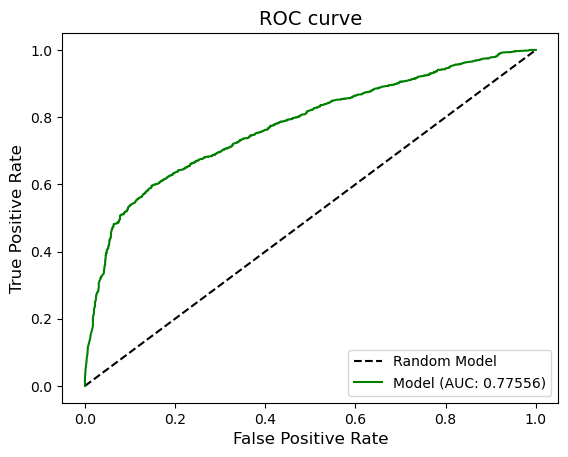

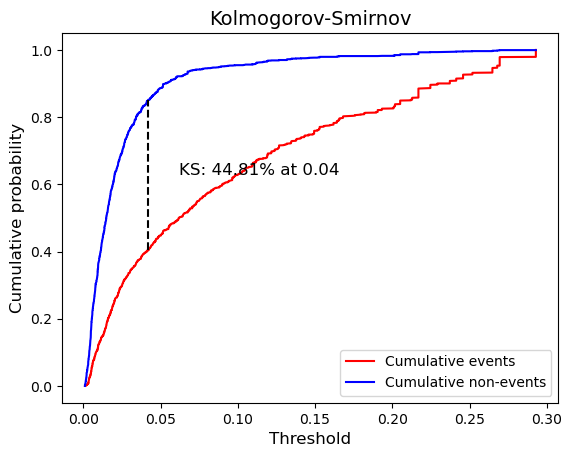

In [ ]:
#model evaluation of initial scorecard on train data
y_pred_train_comb = scorecard_ri.predict_proba(X_train_comb)[:, 1]

plot_auc_roc(y_train_comb, y_pred_train_comb)
plt.show()

plot_ks(y_train_comb, y_pred_train_comb)
plt.show()

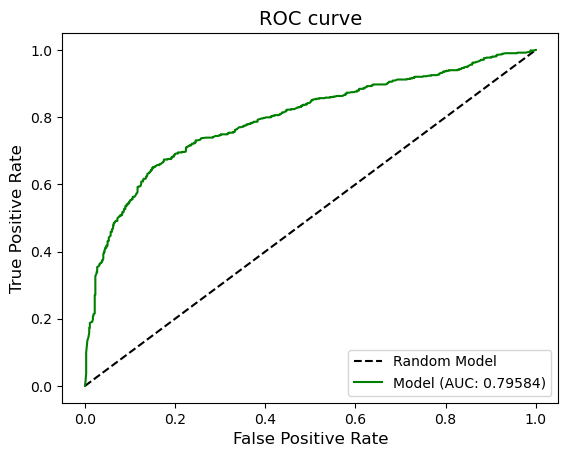

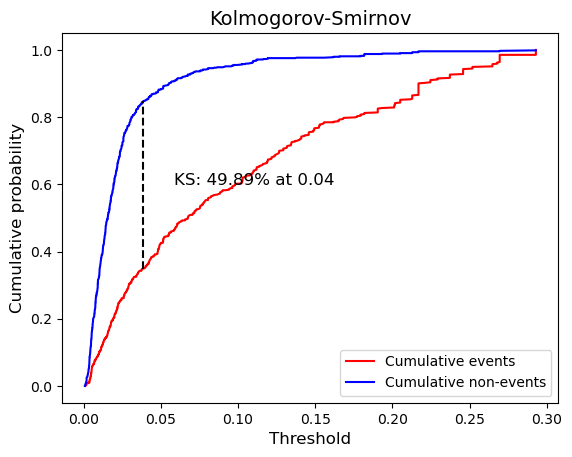

In [ ]:
#model evaluation of initial scorecard on test data
X_test_comb = comb_test[colnames]
y_test_comb = comb_test['GB']

y_pred_test_comb = scorecard_ri.predict_proba(X_test_comb)[:, 1]

plot_auc_roc(y_test_comb, y_pred_test_comb)
plt.show()

plot_ks(y_test_comb, y_pred_test_comb)
plt.show()

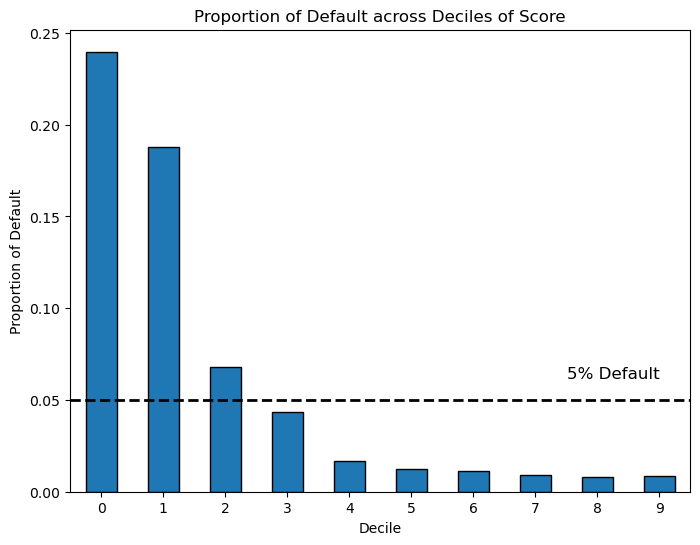

In [ ]:
# score combined dataset on final scorecard and create a decile PD plot
# Recreate canonical split (robust to running this chunk standalone)
test_final = comb_test.copy()

# Ensure weight exists
if '_freq_' not in test_final.columns:
    test_final['_freq_'] = 1.0

# Score using the fitted optbinning scorecard and the predictor list `colnames`
test_final['score'] = scorecard_ri.score(test_final[colnames])

test_final[['score', 'GB']].head()

good_weight = 30

test_final["decile"] = pd.qcut(test_final["score"], 10, labels=False)

# Counts by decile
bad_ct = test_final.loc[test_final['GB'] == 1].groupby("decile").size()
good_ct = test_final.loc[test_final['GB'] == 0].groupby("decile").size()

# Align indices to ensure 0..9 exist
all_dec = pd.Index(range(10), name="decile")
bad_ct = bad_ct.reindex(all_dec, fill_value=0)
good_ct = good_ct.reindex(all_dec, fill_value=0)

PD = bad_ct / (good_ct * good_weight + bad_ct)

plt.figure(figsize=(8, 6))
PD.plot(kind="bar", edgecolor="black")
plt.axhline(y=0.05, color="black", linestyle="--", linewidth=2)
plt.text(x=9, y=0.06, s="5% Default", color="black", ha="right", va="bottom", fontsize=12)

plt.title("Proportion of Default across Deciles of Score")
plt.xlabel("Decile")
plt.ylabel("Proportion of Default")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# create default rate vs acceptance rate graph
def plot_default_and_acceptance_by_score(
    df: pd.DataFrame,
    score_col: str = "score",
    bad_col: str = "bad",
    weight_col: str | None = None,
    n_bins: int = 250,
    smooth_window: int | None = 9,
    title: str = "Default Rate by Acceptance Across Score",
):
    keep_cols = [score_col, bad_col] + ([weight_col] if weight_col else [])
    d = df[keep_cols].copy()
    d = d.dropna(subset=[score_col, bad_col])

    d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
    d[bad_col] = pd.to_numeric(d[bad_col], errors="coerce").astype(int)

    if weight_col and weight_col in d.columns:
        d[weight_col] = pd.to_numeric(d[weight_col], errors="coerce").fillna(0.0)
    else:
        d["_w"] = 1.0
        weight_col = "_w"

    d = d.dropna(subset=[score_col, bad_col])

    # Bin scores to stabilize the curve
    q = min(n_bins, max(5, d.shape[0]))
    d["_bin"] = pd.qcut(d[score_col], q=q, duplicates="drop")
    d["_score_mid"] = d["_bin"].apply(lambda x: (x.left + x.right) / 2.0).astype(float)

    # Aggregate per bin using in-frame weights (avoids index alignment bugs)
    grp = d.groupby("_score_mid", as_index=False).apply(
        lambda g: pd.Series({
            "wt": float(g[weight_col].sum()),
            "bad_wt": float((g[bad_col] * g[weight_col]).sum())
        })
    ).reset_index(drop=True)

    grp = grp.sort_values("_score_mid", ascending=False).reset_index(drop=True)

    total_wt = grp["wt"].sum()
    grp["cum_wt"] = grp["wt"].cumsum()
    grp["cum_bad_wt"] = grp["bad_wt"].cumsum()

    grp["accept_rate_pct"] = 100.0 * grp["cum_wt"] / total_wt
    grp["default_rate_pct"] = 100.0 * grp["cum_bad_wt"] / grp["cum_wt"]

    if smooth_window and smooth_window > 1:
        grp["accept_rate_pct"] = grp["accept_rate_pct"].rolling(
            window=smooth_window, min_periods=1
        ).mean()
        grp["default_rate_pct"] = grp["default_rate_pct"].rolling(
            window=smooth_window, min_periods=1
        ).mean()

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(grp["_score_mid"], grp["default_rate_pct"], label="Default Rate (%)")
    ax1.set_xlabel("Scorecard Value")
    ax1.set_ylabel("Default Rate (%)")
    ax1.set_title(title)

    ax2 = ax1.twinx()
    ax2.plot(grp["_score_mid"], grp["accept_rate_pct"], label="Acceptance Rate (%)")
    ax2.set_ylabel("Acceptance Rate (%)")
    ax2.set_ylim(0, 100)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

    plt.tight_layout()
    plt.show()
    return grp

/var/folders/c_/jf8ypvhn2yg54pjgwwghy0s80000gn/T/ipykernel_72071/1904891785.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = d.groupby("_score_mid", as_index=False).apply(


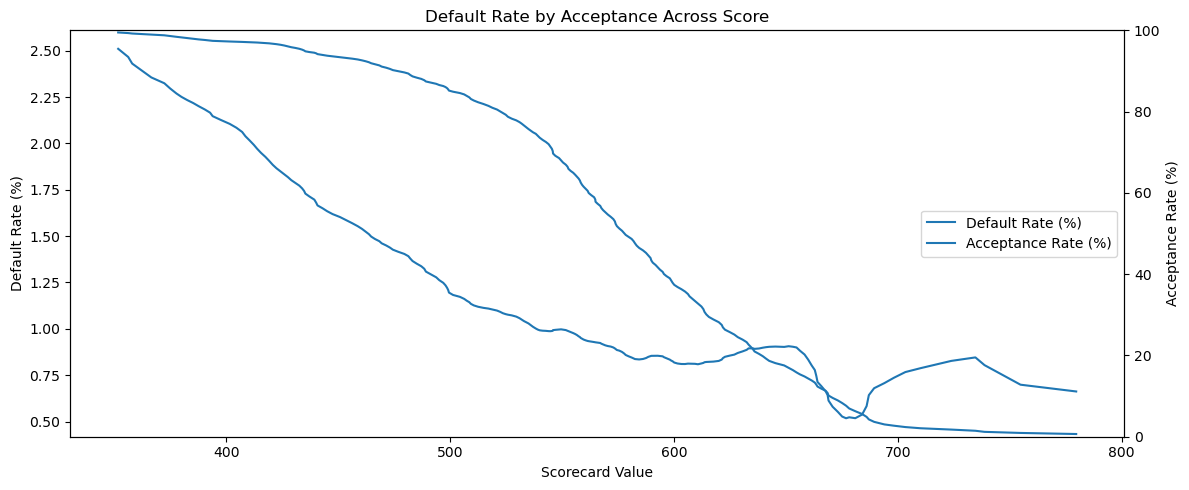

,_score_mid,wt,bad_wt,cum_wt,cum_bad_wt,accept_rate_pct,default_rate_pct
0,779.6415,151.0,1.0,151.0,1.0,0.664525,0.662252
1,754.7660,121.0,1.0,272.0,2.0,0.930775,0.698773
2,738.6880,122.0,2.0,394.0,4.0,1.198492,0.804258
3,734.6140,121.0,1.0,515.0,5.0,1.465476,0.845912
4,723.8395,150.0,0.0,665.0,5.0,1.757690,0.827106


In [ ]:
# default rate vs. acceptance rate graph
curve = plot_default_and_acceptance_by_score(
    test_final,
    score_col="score",
    bad_col='GB',
    weight_col='_freq_' if '_freq_' in test_final.columns else None,
    n_bins=250,
    smooth_window=9,
    title="Default Rate by Acceptance Across Score"
)

curve.head()

In [ ]:
# create profit vs. acceptance rate graph
def plot_profit_and_acceptance_by_score(
    df: pd.DataFrame,
    score_col: str = "score",
    bad_col: str = "bad",
    weight_col: str | None = None,
    profit_if_good: float = 2000.0,
    loss_if_bad: float = 20000.0,
    n_bins: int = 250,
    smooth_window: int | None = 9,
    title: str = "Profit by Acceptance Across Score",
):
    """
    Plot cumulative expected Profit ($) vs Acceptance Rate (%) across score cutoffs.

    For each cutoff score c:
      accepted = rows with score >= c
      acceptance rate = accepted / total
      profit($) = sum_over_accepted( weight * (profit_if_good*(1-bad) - loss_if_bad*bad) )
    """
    keep_cols = [score_col, bad_col] + ([weight_col] if weight_col else [])
    d = df[keep_cols].copy()
    d = d.dropna(subset=[score_col, bad_col])

    d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
    d[bad_col] = pd.to_numeric(d[bad_col], errors="coerce").astype(int)

    if weight_col and weight_col in d.columns:
        d[weight_col] = pd.to_numeric(d[weight_col], errors="coerce").fillna(0.0)
    else:
        d["_w"] = 1.0
        weight_col = "_w"

    d = d.dropna(subset=[score_col, bad_col])

    # Per-row profit contribution
    d["_profit"] = d[weight_col] * (profit_if_good * (1 - d[bad_col]) - loss_if_bad * d[bad_col])

    # Bin scores to stabilize the curve
    q = min(n_bins, max(5, d.shape[0]))
    d["_bin"] = pd.qcut(d[score_col], q=q, duplicates="drop")
    d["_score_mid"] = d["_bin"].apply(lambda x: (x.left + x.right) / 2.0).astype(float)

    # Aggregate per bin (index-safe)
    grp = d.groupby("_score_mid", as_index=False).apply(
        lambda g: pd.Series({
            "wt": float(g[weight_col].sum()),
            "profit": float(g["_profit"].sum()),
        })
    ).reset_index(drop=True)

    grp = grp.sort_values("_score_mid", ascending=False).reset_index(drop=True)

    total_wt = grp["wt"].sum()
    grp["cum_wt"] = grp["wt"].cumsum()
    grp["cum_profit"] = grp["profit"].cumsum()

    grp["accept_rate_pct"] = 100.0 * grp["cum_wt"] / total_wt

    # Optional smoothing (rolling mean)
    if smooth_window and smooth_window > 1:
        grp["accept_rate_pct"] = grp["accept_rate_pct"].rolling(
            window=smooth_window, min_periods=1
        ).mean()
        grp["cum_profit"] = grp["cum_profit"].rolling(
            window=smooth_window, min_periods=1
        ).mean()

    # Plot with two y-axes
    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(grp["_score_mid"], grp["cum_profit"], label="Profit ($)")
    ax1.set_xlabel("Scorecard Value")
    ax1.set_ylabel("Profit ($)")
    ax1.set_title(title)

    ax2 = ax1.twinx()
    ax2.plot(grp["_score_mid"], grp["accept_rate_pct"], label="Acceptance Rate (%)")
    ax2.set_ylabel("Acceptance Rate (%)")
    ax2.set_ylim(0, 100)

    # Combined legend on the right
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

    plt.tight_layout()
    plt.show()

    return grp

/var/folders/c_/jf8ypvhn2yg54pjgwwghy0s80000gn/T/ipykernel_72071/3869993872.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = d.groupby("_score_mid", as_index=False).apply(


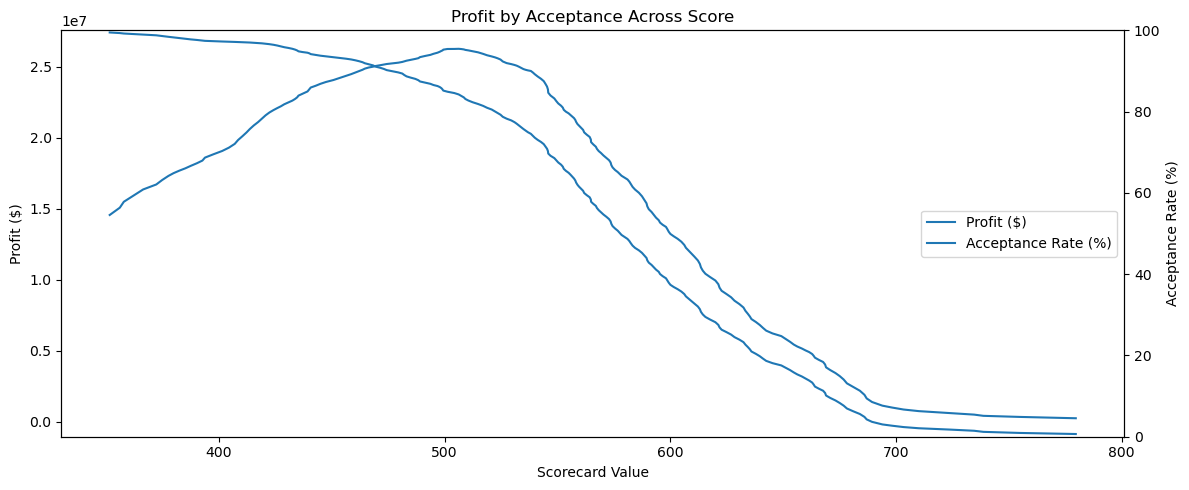

,_score_mid,wt,profit,cum_wt,cum_profit,accept_rate_pct
0,779.6415,151.0,248000.0,151.0,248000.000000,0.664525
1,754.7660,121.0,188000.0,272.0,342000.000000,0.930775
2,738.6880,122.0,136000.0,394.0,418666.666667,1.198492
3,734.6140,121.0,188000.0,515.0,504000.000000,1.465476
4,723.8395,150.0,300000.0,665.0,615200.000000,1.757690


In [ ]:
# profit vs. acceptance rate graph
profit_if_good = 2000.0   # profit on a good loan
loss_if_bad    = 52000.0 # loss on a bad loan (positive number)

profit_curve = plot_profit_and_acceptance_by_score(
    test_final,
    score_col="score",
    bad_col="GB",
    weight_col="_freq_" if "_freq_" in test_final.columns else None,
    profit_if_good=profit_if_good,
    loss_if_bad=loss_if_bad,
    n_bins=250,
    smooth_window=9,
    title="Profit by Acceptance Across Score"
)

profit_curve.head()



In [ ]:
profit_curve[profit_curve['cum_profit'] == max(profit_curve['cum_profit'])]

,_score_mid,wt,profit,cum_wt,cum_profit,accept_rate_pct
158,506.249,94.0,-28000.0,19435.0,26272000.0,84.227435


In [ ]:
curve[curve['default_rate_pct']<=3.23].sort_values(by='default_rate_pct', ascending=False)

,_score_mid,wt,bad_wt,cum_wt,cum_bad_wt,accept_rate_pct,default_rate_pct
235,351.6515,83.0,23.0,22723.0,613.0,99.476791,2.510013
234,356.1255,3.0,3.0,22640.0,590.0,99.326673,2.466037
233,357.9105,5.0,5.0,22637.0,587.0,99.215186,2.430313
232,362.0900,14.0,14.0,22632.0,582.0,99.088051,2.393937
231,366.4660,7.0,7.0,22618.0,568.0,98.958960,2.355583
...,...,...,...,...,...,...,...
12,683.9885,303.0,3.0,1961.0,11.0,5.588562,0.537656
16,675.0840,121.0,1.0,2475.0,15.0,8.289203,0.527011
14,678.2455,122.0,2.0,2204.0,14.0,6.945973,0.522988
13,680.9520,121.0,1.0,2082.0,12.0,6.281448,0.518155


In [ ]:
curve[curve['accept_rate_pct']>=75].sort_values(by='accept_rate_pct', ascending=True)

,_score_mid,wt,bad_wt,cum_wt,cum_bad_wt,accept_rate_pct,default_rate_pct
137,535.9565,62.0,2.0,17406.0,186.0,75.304024,1.020448
138,534.9490,181.0,1.0,17587.0,187.0,75.710856,1.029171
139,533.9615,150.0,0.0,17737.0,187.0,76.145560,1.035520
140,532.9335,92.0,2.0,17829.0,189.0,76.580264,1.041801
141,531.9665,93.0,3.0,17922.0,192.0,77.015946,1.049274
...,...,...,...,...,...,...,...
231,366.4660,7.0,7.0,22618.0,568.0,98.958960,2.355583
232,362.0900,14.0,14.0,22632.0,582.0,99.088051,2.393937
233,357.9105,5.0,5.0,22637.0,587.0,99.215186,2.430313
234,356.1255,3.0,3.0,22640.0,590.0,99.326673,2.466037


Final Cutoffs
1. anyone who has score above 558.97 (559) is accepted automatically because that maximizes profit
2. anyone with scores below 528 are declined because that is our current acceptance rate
3. anyone between 528 and 559 are referred to manual adjudication